# Regressão Linear, Valor de Probabilidade e Métricas

In [284]:
# Importando bibliotecas que serão usadas: 
import numpy as np
import random
import matplotlib.pyplot as plt
from scipy import stats

## A $)$

### Geração de Gráficos, uso de Regressão Linear e cálculo de Covariância:

Gerar valores similares aos das seguintes figuras, para isso define-se primeiramente uma "semente", que define valores iniciais para geradores de números pseudoaleatórios, com o objetivo de garantir a reprodutibilidade, o que facilita futuras análises de resultado.

<div style="display: flex; justify-content: center; gap: 20px;">
  <img src="assets/atv_4/A_func1.png" width="300">
  <img src="assets/atv_4/A_func2.png" width="300">
</div>

In [285]:
np.random.seed(3994)

Primeira Figura:

In [286]:
# Gráfico 1
x1 = np.random.rand(9) * 2 + 1                              # Cria um vetor com números float aleatórios entre (0,1) e os valores são multiplicados por 2 e soma por 1, é uma distribuição uniforme
y1 = x1 + 0.1                                               # Função y em que cada x da lista é somado com mais 0.1
                                                            # x1 e y1 são para o gráfico 1

media_x1 = sum(x1) / len(x1)                                # Média do X do gráfico 1
media_y1 = sum(y1) / len(y1)                                # Média do Y do gráfico 1
covariancia_1 = sum((x1[i] - media_x1) * (y1[i] - media_y1) for i in range(len(x1)) ) / (len(x1) - 1)
                                                            # Cálculo da covariância usando list comprehension
resultado1 = stats.linregress(x1, y1)                       # Nesta parte realiza-se a Regressão Linear para o gráfico 1
pvalue1 = resultado1.pvalue                                 # Valor de probabilidade retornado pela Regressão Linear 1

linha_X1 = np.linspace(0, 4, 2)                             # Se cria um vetor com valores que serão usados para desenhar o gráfico
linha_Y1 = resultado1.slope * linha_X1 + resultado1.intercept 
                                                            # Aqui se usa o slope(coeficiente angular) e o intercept(coeficiente linear)

# Gráfico 2

x2 = np.random.uniform(1, 3, 9)                             # Cria um vetor com distribuição uniforme no intervalo (0,3)
y2 = np.random.uniform(1, 3, 9)                             # Cria um vetor com distribuição uniforme no intervalo (0,3) 

media_x2 = sum(x2) / len(x2)                                # Média do X no gráfico 2
media_y2 = sum(y2) / len(y2)                                # Média do Y no gráfico 2

covariancia_2 = sum((x2[i] - media_x2) * (y2[i] - media_y2) for i in range(len(x2)) ) / (len(x2) - 1)
                                                            # Cálculo da covariância usando list comprehension
resultado2 = stats.linregress(x2, y2)                       # Regressão Linear para o gráfico 2
pvalue2 = resultado2.pvalue                                 # Valor de probabilidade retornado pela Regressão Linear 2


linha_X2 = np.linspace(0, 4, 2)
linha_Y2 = resultado2.slope * linha_X2 + resultado2.intercept

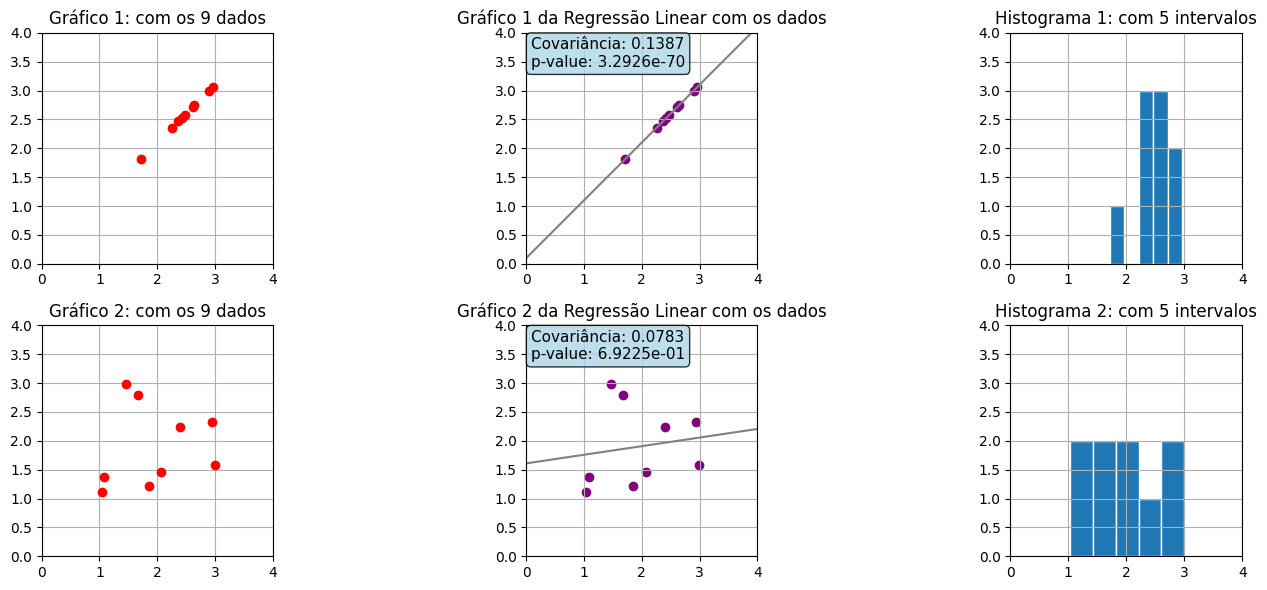

In [287]:
fig, axs= plt.subplots(2, 3, figsize=(16,6))

graph1 = axs[0,0]
graph2 = axs[0,1]
graph3 = axs[0,2]

graph4 = axs[1,0]
graph5 = axs[1,1]
graph6 = axs[1,2]


# Gráfico 1, plotando apenas os 9 pontos
graph1.plot(x1, y1, 'o', color='red')
graph1.set_title('Gráfico 1: com os 9 dados')
graph1.grid(True)
graph1.set_aspect('equal', adjustable='box')
graph1.set_xlim(0,4)
graph1.set_ylim(0,4)

# Gráfico 2, exibindo os 9 valores sob a reta e a reta da Regressão Linear 1
graph2.scatter(x1, y1, color='purple')
graph2.plot(linha_X1, linha_Y1, color='grey')
graph2.set_title('Gráfico 1 da Regressão Linear com os dados')
graph2.grid(True)
graph2.set_aspect('equal', adjustable='box')
graph2.set_xlim(0,4)
graph2.set_ylim(0,4)

info_text1 = (f"Covariância: {covariancia_1:.4f}\n" f"p-value: {pvalue1:.4e}")
graph2.text( 0.02, 0.98, info_text1, transform=graph2.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gráfico 3, mostrando o agrupamento dos 9 valores num bin = 5
graph3.hist(x1, bins=5, edgecolor='white')
graph3.set_title('Histograma 1: com 5 intervalos')
graph3.set_xlim(0,4)
graph3.set_ylim(0,4)
graph3.grid(True)
graph3.set_aspect(0.995) 

# Gráfico 4, mostrando a disposição dos dados no segundo caso
graph4.plot(x2, y2, 'o', color='red')
graph4.set_title('Gráfico 2: com os 9 dados')
graph4.grid(True)
graph4.set_aspect('equal', adjustable='box')
graph4.set_xlim(0,4)
graph4.set_ylim(0,4)

# Gráfico 5, exibindo os 9 valores sob a reta e a reta da Regressão Linear 2
graph5.scatter(x2, y2, color='purple')
graph5.plot(linha_X2, linha_Y2, color='grey')
graph5.set_title('Gráfico 2 da Regressão Linear com os dados')
graph5.grid(True)
graph5.set_aspect('equal', adjustable='box')
graph5.set_xlim(0,4)
graph5.set_ylim(0,4)

info_text2 = (f"Covariância: {covariancia_2:.4f}\n" f"p-value: {pvalue2:.4e}")
graph5.text( 0.02, 0.98, info_text2, transform=graph5.transAxes, fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))

# Gráfico 6, msotrando o agrupamento dos 9 valores num bin = 5 para o segundo caso
graph6.hist(x2, bins=5, edgecolor='white')
graph6.set_title('Histograma 2: com 5 intervalos')
graph6.set_xlim(0,4)
graph6.set_ylim(0,4)
graph6.grid(True)
graph6.set_aspect(0.995) 

plt.tight_layout()
plt.show()

Segunda Figura: